Carregando o Banco Mundial inteiro...


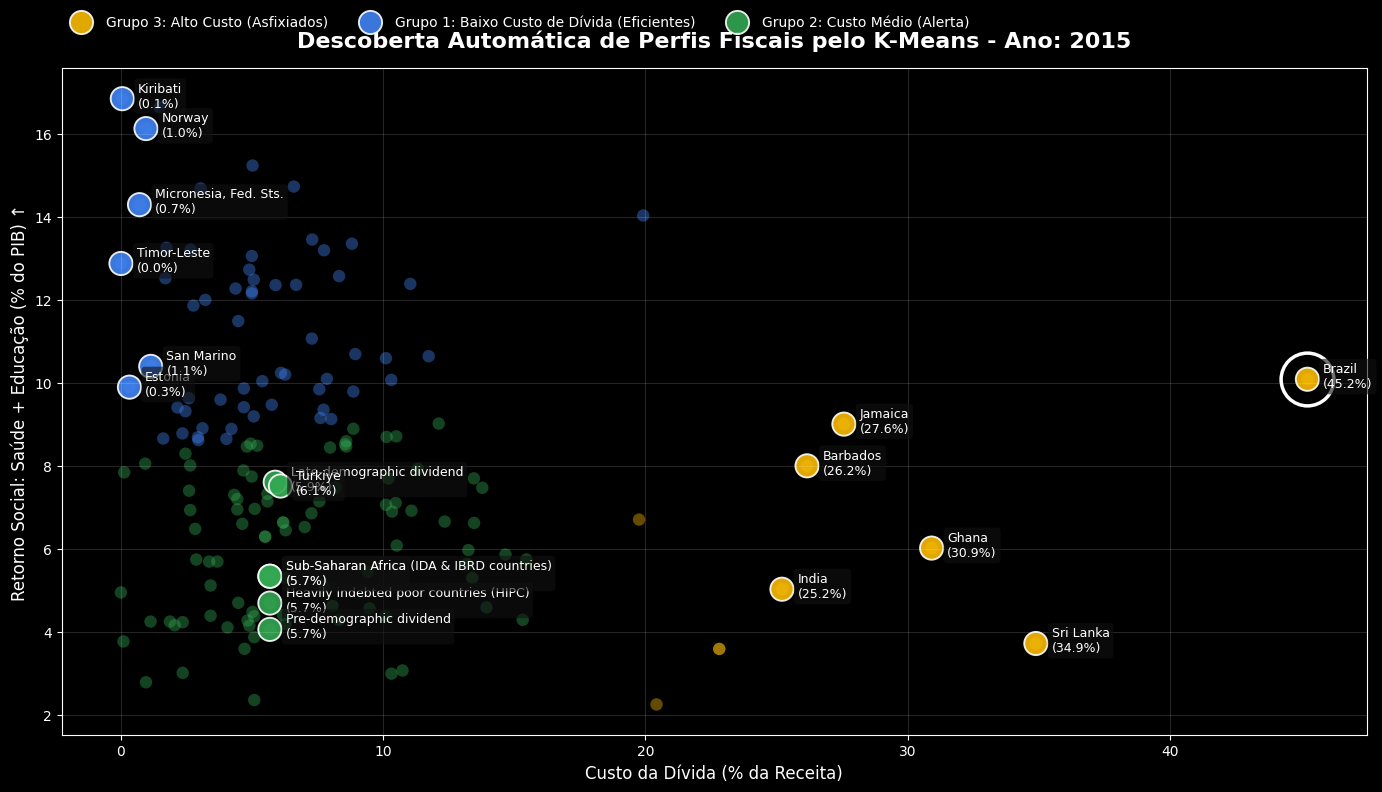


RELATÓRIO DE DESCOBERTA DO K-MEANS

[Grupo 1: Baixo Custo de Dívida (Eficientes)]
-> Quantidade de Países neste grupo: 59
-> Média de Gasto com Dívida: 5.2%
-> Média de Gasto Social: 11.4%
-> Quem são os líderes em juros deste grupo? Iceland, Portugal, Costa Rica, South Africa

[Grupo 2: Custo Médio (Alerta)]
-> Quantidade de Países neste grupo: 95
-> Média de Gasto com Dívida: 6.8%
-> Média de Gasto Social: 6.1%
-> Quem são os líderes em juros deste grupo? Malawi, Philippines, St. Lucia, Bahamas, The

[Grupo 3: Alto Custo (Asfixiados)]
-> Quantidade de Países neste grupo: 10
-> Média de Gasto com Dívida: 27.6%
-> Média de Gasto Social: 5.8%
-> Quem são os líderes em juros deste grupo? Brazil, Sri Lanka, Ghana, Jamaica


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import glob

print("Carregando o Banco Mundial inteiro...")
arq_edu = glob.glob('API_SE.XPD.TOTL.GD.ZS*.csv')
arq_sau = glob.glob('API_SH.XPD.GHED.GD.ZS*.csv')
arq_div = glob.glob('API_GC.XPN.INTP.RV.ZS*.csv')

df_edu = pd.read_csv(arq_edu[0], skiprows=4)
df_sau = pd.read_csv(arq_sau[0], skiprows=4)
df_div = pd.read_csv(arq_div[0], skiprows=4)

ano = '2015'

# 1. PREPARAÇÃO DOS DADOS (O Mundo Todo Sem Filtros)
edu = df_edu[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Educacao_PIB'})
sau = df_sau[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Saude_PIB'})
div = df_div[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Pagamento_Total_Divida'})

df_global = edu.merge(sau, on=['Country Code', 'Country Name']).merge(div, on=['Country Code', 'Country Name'])
df_global['Gasto_Social'] = df_global['Educacao_PIB'] + df_global['Saude_PIB']
df_global = df_global.dropna()

# 2. O ALGORITMO ASSUME O CONTROLE CEGAMENTE
X = df_global[['Pagamento_Total_Divida', 'Gasto_Social']]
X_padronizado = StandardScaler().fit_transform(X)
df_global['Cluster_ID'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_padronizado)

# 3. O ALGORITMO NOMEIA OS GRUPOS SOZINHO (Baseado na Média Matemática)
centroides = df_global.groupby('Cluster_ID')[['Pagamento_Total_Divida', 'Gasto_Social']].mean()
id_baixo_juros = centroides['Pagamento_Total_Divida'].idxmin()
id_alto_juros = centroides['Pagamento_Total_Divida'].idxmax()
id_medio_juros = [i for i in range(3) if i not in [id_baixo_juros, id_alto_juros]][0]

df_global['Nome_Cluster'] = df_global['Cluster_ID'].map({
    id_baixo_juros: 'Grupo 1: Baixo Custo de Dívida (Eficientes)',
    id_medio_juros: 'Grupo 2: Custo Médio (Alerta)',
    id_alto_juros: 'Grupo 3: Alto Custo (Asfixiados)'
})

# 4. SELEÇÃO AUTOMÁTICA DOS RÓTULOS (Para o gráfico ficar limpo)
# O código pega os piores exemplos do Grupo 3, e os melhores exemplos do Grupo 1
top_asfixiados = df_global[df_global['Cluster_ID'] == id_alto_juros].nlargest(6, 'Pagamento_Total_Divida')
top_eficientes = df_global[df_global['Cluster_ID'] == id_baixo_juros].nsmallest(6, 'Pagamento_Total_Divida')

# Para o grupo médio, pega os que estão exatamente no meio (mediana)
mediana_grupo2 = df_global[df_global['Cluster_ID'] == id_medio_juros]['Pagamento_Total_Divida'].median()
df_medio = df_global[df_global['Cluster_ID'] == id_medio_juros].copy()
df_medio['Distancia'] = abs(df_medio['Pagamento_Total_Divida'] - mediana_grupo2)
top_medios = df_medio.nsmallest(6, 'Distancia')

# Junta quem vai ganhar etiqueta de texto
df_rotulos = pd.concat([top_asfixiados, top_eficientes, top_medios])

# Força o Brasil aparecer na etiqueta se ele existir na base global
if 'BRA' in df_global['Country Code'].values and 'BRA' not in df_rotulos['Country Code'].values:
    df_rotulos = pd.concat([df_rotulos, df_global[df_global['Country Code'] == 'BRA']])

# 5. VISUALIZAÇÃO
plt.figure(figsize=(14, 8))
plt.style.use('dark_background')
cores = {'Grupo 1: Baixo Custo de Dívida (Eficientes)': '#4285F4', 'Grupo 2: Custo Médio (Alerta)': '#34A853', 'Grupo 3: Alto Custo (Asfixiados)': '#FBBC05'}

# Plota TODOS os países do mundo como bolhas pequenas de fundo
sns.scatterplot(data=df_global, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=80, alpha=0.4, edgecolor='none', legend=False)

# Plota em Destaque apenas a amostra selecionada
sns.scatterplot(data=df_rotulos, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=280, alpha=0.9, edgecolor='white', legend='full')

for i in range(df_rotulos.shape[0]):
    plt.annotate(f"{df_rotulos['Country Name'].iloc[i]}\n({df_rotulos['Pagamento_Total_Divida'].iloc[i]:.1f}%)",
                 (df_rotulos['Pagamento_Total_Divida'].iloc[i] + 0.6, df_rotulos['Gasto_Social'].iloc[i] - 0.2), fontsize=9, color='white',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#111111", alpha=0.6, ec="none"))

# Destaca o Brasil
brasil_data = df_rotulos[df_rotulos['Country Code'] == 'BRA']
if not brasil_data.empty:
    plt.plot(brasil_data['Pagamento_Total_Divida'].values[0], brasil_data['Gasto_Social'].values[0], 'o', ms=38, mec='white', mfc='none', mew=2.5)

plt.title(f'Descoberta Automática de Perfis Fiscais pelo K-Means - Ano: {ano}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Custo da Dívida (% da Receita)', fontsize=12)
plt.ylabel('Retorno Social: Saúde + Educação (% do PIB) ↑', fontsize=12)
plt.legend(bbox_to_anchor=(0, 1.05), loc='lower left', borderaxespad=0, ncol=3, frameon=False, fontsize=10)
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

# 6. RELATÓRIO TEXTUAL AUTOMÁTICO PARA A SUA ANÁLISE
print("\n" + "="*60)
print("RELATÓRIO DE DESCOBERTA DO K-MEANS")
print("="*60)
for nome_grupo in sorted(df_global['Nome_Cluster'].unique()):
    grupo = df_global[df_global['Nome_Cluster'] == nome_grupo]
    print(f"\n[{nome_grupo}]")
    print(f"-> Quantidade de Países neste grupo: {len(grupo)}")
    print(f"-> Média de Gasto com Dívida: {grupo['Pagamento_Total_Divida'].mean():.1f}%")
    print(f"-> Média de Gasto Social: {grupo['Gasto_Social'].mean():.1f}%")
    print(f"-> Quem são os líderes em juros deste grupo? {', '.join(grupo.nlargest(4, 'Pagamento_Total_Divida')['Country Name'].tolist())}")
print("="*60)

Carregando o Banco Mundial inteiro...


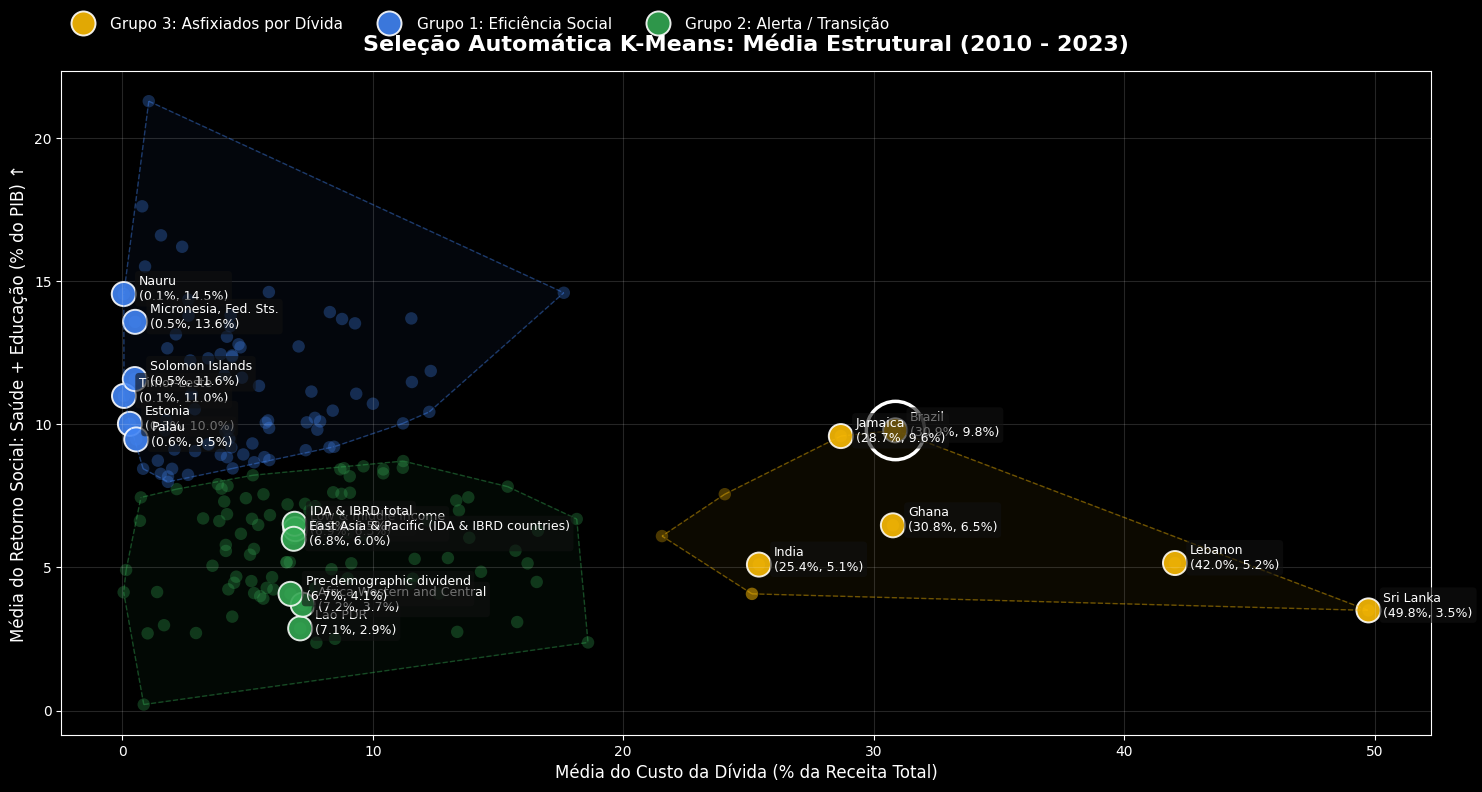

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import glob

print("Carregando o Banco Mundial inteiro...")
arq_edu = glob.glob('API_SE.XPD.TOTL.GD.ZS*.csv')
arq_sau = glob.glob('API_SH.XPD.GHED.GD.ZS*.csv')
arq_div = glob.glob('API_GC.XPN.INTP.RV.ZS*.csv')

df_edu = pd.read_csv(arq_edu[0], skiprows=4)
df_sau = pd.read_csv(arq_sau[0], skiprows=4)
df_div = pd.read_csv(arq_div[0], skiprows=4)

# 1. DEFINIÇÃO DO PERÍODO EXATO (2010 a 2023)
anos_analise = [str(ano) for ano in range(2010, 2024)]

# 2. CÁLCULO AUTOMÁTICO DA MÉDIA HISTÓRICA PARA O MUNDO TODO
def calcular_media_periodo(df, nome_coluna):
    anos_validos = [ano for ano in anos_analise if ano in df.columns]
    df_resumo = df[['Country Code', 'Country Name']].copy()
    df_resumo[nome_coluna] = df[anos_validos].mean(axis=1)
    return df_resumo

edu = calcular_media_periodo(df_edu, 'Educacao_PIB')
sau = calcular_media_periodo(df_sau, 'Saude_PIB')
div = calcular_media_periodo(df_div, 'Pagamento_Total_Divida')

# Consolidando a base global limpa
df_global = edu.merge(sau, on=['Country Code', 'Country Name']).merge(div, on=['Country Code', 'Country Name'])
df_global['Gasto_Social'] = df_global['Educacao_PIB'] + df_global['Saude_PIB']
df_global = df_global.dropna()

# 3. O ALGORITMO RODA ÀS CEGAS (K-MEANS)
X = df_global[['Pagamento_Total_Divida', 'Gasto_Social']]
X_padronizado = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_global['Cluster_ID'] = kmeans.fit_predict(X_padronizado)

# Auto-identificação e Nomenclatura Matemática
centroides = df_global.groupby('Cluster_ID')[['Pagamento_Total_Divida', 'Gasto_Social']].mean()
id_baixo_juros = centroides['Pagamento_Total_Divida'].idxmin()
id_alto_juros = centroides['Pagamento_Total_Divida'].idxmax()
id_medio_juros = [i for i in range(3) if i not in [id_baixo_juros, id_alto_juros]][0]

df_global['Nome_Cluster'] = df_global['Cluster_ID'].map({
    id_baixo_juros: 'Grupo 1: Eficiência Social',
    id_medio_juros: 'Grupo 2: Alerta / Transição',
    id_alto_juros: 'Grupo 3: Asfixiados por Dívida'
})

# 4. A SELEÇÃO INTELIGENTE: 6 PAÍSES POR GRUPO
# Pega os 6 melhores do Grupo 1 e os 6 piores do Grupo 3
top_eficientes = df_global[df_global['Cluster_ID'] == id_baixo_juros].nsmallest(6, 'Pagamento_Total_Divida')
top_asfixiados = df_global[df_global['Cluster_ID'] == id_alto_juros].nlargest(6, 'Pagamento_Total_Divida')

# Para o Grupo 2, pega os 6 países mais próximos do meio exato (mediana) do grupo
mediana_grupo2 = df_global[df_global['Cluster_ID'] == id_medio_juros]['Pagamento_Total_Divida'].median()
df_medio = df_global[df_global['Cluster_ID'] == id_medio_juros].copy()
df_medio['Distancia'] = abs(df_medio['Pagamento_Total_Divida'] - mediana_grupo2)
top_medios = df_medio.nsmallest(6, 'Distancia')

# Consolida os escolhidos pelo algoritmo
df_destaque = pd.concat([top_asfixiados, top_eficientes, top_medios])

# Trava de Segurança: Força o Brasil a aparecer com texto se o algoritmo não o colocou no Top 6 dos Asfixiados
if 'BRA' in df_global['Country Code'].values and 'BRA' not in df_destaque['Country Code'].values:
    df_destaque = pd.concat([df_destaque, df_global[df_global['Country Code'] == 'BRA']])

# 5. CONSTRUÇÃO VISUAL DO DASHBOARD
plt.figure(figsize=(15, 8))
plt.style.use('dark_background')
cores = {'Grupo 1: Eficiência Social': '#4285F4', 'Grupo 2: Alerta / Transição': '#34A853', 'Grupo 3: Asfixiados por Dívida': '#FBBC05'}

# Plota TODOS os países do mundo agrupados no fundo (bolhas opacas)
sns.scatterplot(data=df_global, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=80, alpha=0.3, edgecolor='none', legend=False)

# Plota com Destaque apenas os 18 países escolhidos dinamicamente pelo algoritmo
sns.scatterplot(data=df_destaque, x='Pagamento_Total_Divida', y='Gasto_Social', hue='Nome_Cluster', palette=cores, s=300, alpha=0.9, edgecolor='white', legend='full')

# Desenha os polígonos baseados na realidade do mundo todo
for nome, grupo in df_global.groupby('Nome_Cluster'):
    pontos = grupo[['Pagamento_Total_Divida', 'Gasto_Social']].values
    if len(pontos) >= 3:
        hull = ConvexHull(pontos)
        for simplex in hull.simplices:
            plt.plot(pontos[simplex, 0], pontos[simplex, 1], color=cores[nome], linestyle='--', linewidth=1.0, alpha=0.4)
        plt.fill(pontos[hull.vertices, 0], pontos[hull.vertices, 1], color=cores[nome], alpha=0.05)

# Insere os Rótulos Textuais
for i in range(df_destaque.shape[0]):
    plt.annotate(f"{df_destaque['Country Name'].iloc[i]}\n({df_destaque['Pagamento_Total_Divida'].iloc[i]:.1f}%, {df_destaque['Gasto_Social'].iloc[i]:.1f}%)",
                 (df_destaque['Pagamento_Total_Divida'].iloc[i] + 0.6, df_destaque['Gasto_Social'].iloc[i] - 0.2), fontsize=9, color='white',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#111111", alpha=0.6, ec="none"))

# Destaca o Brasil com o círculo grosso para ser o centro da apresentação
brasil_data = df_destaque[df_destaque['Country Code'] == 'BRA']
if not brasil_data.empty:
    plt.plot(brasil_data['Pagamento_Total_Divida'].values[0], brasil_data['Gasto_Social'].values[0], 'o', ms=42, mec='white', mfc='none', mew=2.5)

# Ajustes Finais
plt.title('Seleção Automática K-Means: Média Estrutural (2010 - 2023)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Média do Custo da Dívida (% da Receita Total)', fontsize=12)
plt.ylabel('Média do Retorno Social: Saúde + Educação (% do PIB) ↑', fontsize=12)
plt.legend(bbox_to_anchor=(0, 1.05), loc='lower left', borderaxespad=0, ncol=3, frameon=False, fontsize=11)
plt.grid(True, alpha=0.15)
plt.tight_layout()

plt.show()

In [10]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

print("Iniciando a Mineração de Regras de Associação (Apriori)...\n")

# 1. DISCRETIZAÇÃO
df_regras = df_global[['Country Name', 'Pagamento_Total_Divida', 'Gasto_Social']].copy()

df_regras['Faixa_Divida'] = pd.qcut(df_regras['Pagamento_Total_Divida'], q=3, labels=['Dívida_Baixa', 'Dívida_Média', 'Dívida_Alta'])
df_regras['Faixa_Social'] = pd.qcut(df_regras['Gasto_Social'], q=3, labels=['Social_Baixo', 'Social_Médio', 'Social_Alto'])

# 2. MATRIZ TRANSACIONAL
df_transacional = pd.get_dummies(df_regras[['Faixa_Divida', 'Faixa_Social']])
df_transacional = df_transacional.astype(bool)

# 3. APRIORI COM FILTROS MAIS REAIS PARA ECONOMIA (5% de suporte mínimo)
itemsets_frequentes = apriori(df_transacional, min_support=0.05, use_colnames=True)

# 4. REGRAS DE ASSOCIAÇÃO (20% de confiança mínima)
regras = association_rules(itemsets_frequentes, metric="confidence", min_threshold=0.20)

regras_finais = regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
regras_finais['antecedents'] = regras_finais['antecedents'].apply(lambda x: list(x)[0])
regras_finais['consequents'] = regras_finais['consequents'].apply(lambda x: list(x)[0])

regras_finais = regras_finais.sort_values(by='lift', ascending=False)

# 5. EXIBINDO O RESULTADO 
print("="*80)
print("AS 5 REGRAS MAIS FORTES DO EFEITO TESOURA (Algoritmo Apriori)")
print("="*80)

for index, row in regras_finais.head(5).iterrows():
    antecedente = row['antecedents'].replace('Faixa_Divida_', '').replace('Faixa_Social_', '')
    consequente = row['consequents'].replace('Faixa_Divida_', '').replace('Faixa_Social_', '')
    
    print(f"REGRA: SE [{antecedente}] ---> ENTÃO [{consequente}]")
    print(f"   • Suporte    : {row['support']*100:.1f}% dos países do mundo caem nessa regra.")
    print(f"   • Confiança  : {row['confidence']*100:.1f}% de probabilidade.")
    print(f"   • Lift       : {row['lift']:.2f}x (Força da correlação)\n")
    
if 'Brazil' in df_regras['Country Name'].values:
    brasil_d = df_regras[df_regras['Country Name'] == 'Brazil']['Faixa_Divida'].values[0]
    brasil_s = df_regras[df_regras['Country Name'] == 'Brazil']['Faixa_Social'].values[0]
    print("-" * 80)
    print(f"DIAGNÓSTICO DO BRASIL: Foi classificado automaticamente com {brasil_d} e {brasil_s}.")
    print("="*80)

Iniciando a Mineração de Regras de Associação (Apriori)...

AS 5 REGRAS MAIS FORTES DO EFEITO TESOURA (Algoritmo Apriori)
REGRA: SE [Dívida_Baixa] ---> ENTÃO [Social_Alto]
   • Suporte    : 16.5% dos países do mundo caem nessa regra.
   • Confiança  : 49.2% de probabilidade.
   • Lift       : 1.47x (Força da correlação)

REGRA: SE [Social_Alto] ---> ENTÃO [Dívida_Baixa]
   • Suporte    : 16.5% dos países do mundo caem nessa regra.
   • Confiança  : 49.2% de probabilidade.
   • Lift       : 1.47x (Força da correlação)

REGRA: SE [Social_Baixo] ---> ENTÃO [Dívida_Alta]
   • Suporte    : 14.9% dos países do mundo caem nessa regra.
   • Confiança  : 44.4% de probabilidade.
   • Lift       : 1.33x (Força da correlação)

REGRA: SE [Dívida_Alta] ---> ENTÃO [Social_Baixo]
   • Suporte    : 14.9% dos países do mundo caem nessa regra.
   • Confiança  : 44.4% de probabilidade.
   • Lift       : 1.33x (Força da correlação)

REGRA: SE [Social_Baixo] ---> ENTÃO [Dívida_Média]
   • Suporte    : 12.8%